# testing HBV from .py 

In [1]:
# setup imports
import sys
from pathlib import Path
import numpy as np
PROJECT_ROOT = Path().resolve().parents[1]  # pas aan als notebook dieper/dichter zit
sys.path.append(str(PROJECT_ROOT))

from src.paths import *
from src.forcing import setup_ERA5_forcing,plot_ERA5_forcing,load_lumped_forcing
from src.models import run_HBV_model,plot_HBV_output,save_HBV_results
from src.utils import catchment_area_from_shapefile

/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498


In [2]:
# The time-window of the experiment
experiment_start_date = "1950-01-01T00:00:00Z"
experiment_end_date = "1955-12-31T00:00:00Z"

shapefile_name = "Tyumen_Aryk_GRDC"

#ERA5_forcing = setup_ERA5_forcing(shapefile_name, "ERA5", experiment_start_date, experiment_end_date)
ERA5_forcing = load_lumped_forcing(shapefile_name, "ERA5")


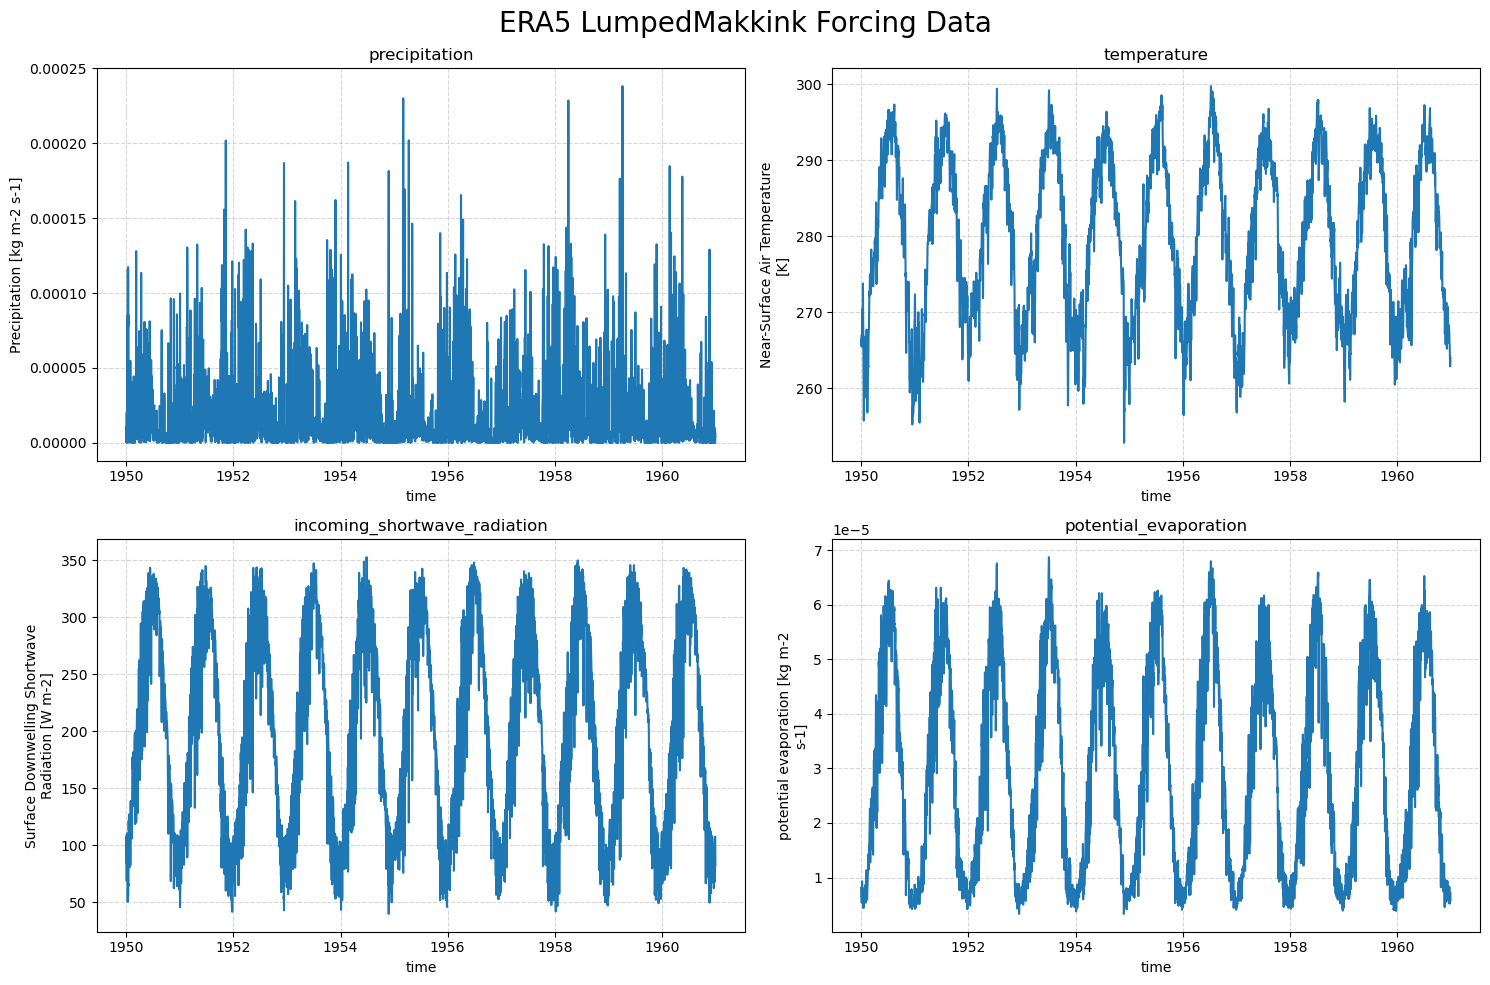

In [3]:
plot_ERA5_forcing(ERA5_forcing)

# HBV model run

In [4]:
parameter_set =  [
    7.085,  # Imax
    0.837,  # Ce
    76.373, # Sumax
    1.112,  # Beta
    0.245,  # Pmax
    7.801,  # Tlag
    0.096,  # Kf
    0.003,  # Ks
    0.226   # FM
]

initial_conditions = np.array([
    0,      # Si
    100,    # Su
    0,      # Sf
    5,      # Ss
    0       # Sp
])

In [6]:

Q_modelled = run_HBV_model(
    forcing=ERA5_forcing,
    parameter_set=parameter_set,
    initial_conditions=initial_conditions,
    show_progress=True  # shows tqdm progress bar
)


print(Q_modelled.head())

Running HBV model:   0%|          | 0/4017 [00:00<?, ?it/s]

1950-01-02 12:00:00    0.000499
1950-01-03 12:00:00    0.002022
1950-01-04 12:00:00    0.004627
1950-01-05 12:00:00    0.008366
1950-01-06 12:00:00    0.012296
Name: Modelled_discharge, dtype: float64


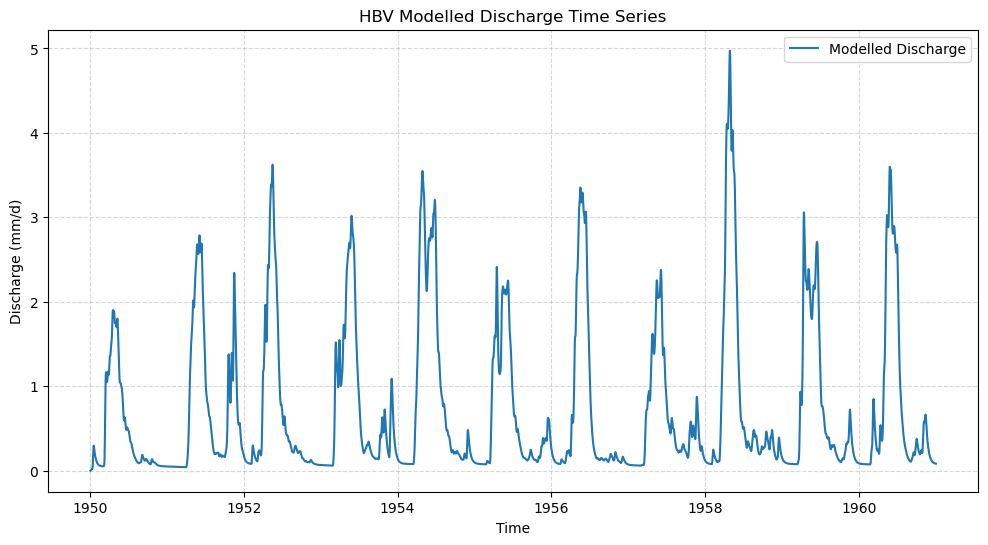

In [7]:
plot_HBV_output(Q_modelled)

In [8]:
files= save_HBV_results(Q_modelled, shape_name=shapefile_name, forcing_type="ERA5")

In [9]:
files["csv"]

PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/outputs/model_runs/HBV/Tyumen_Aryk_GRDC/ERA5/Tyumen_Aryk_GRDC_ERA5_1950-1960.csv')